In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#reading updated dataset containing alignment scores
data = pd.read_csv("dataset_with_scores.csv")
print(f"Articles: {len(data)}")
data[["title","year","alignment_score"]].head()

Articles: 1530


,title,year,alignment_score
0,AI-assisted anatomical structure recognition a...,2025,0.651630
1,On Consensus-Optimality Trade-offs in Collabor...,2021,0.639026
2,Reduction of Survey Sites in Dialectology: A N...,2021,0.717490
3,Reconstructing signal during brain stimulation...,2025,0.689414
4,Closed-Form Results for Prior Constraints in S...,2021,0.747429


In [3]:
#overview of dataset
data["alignment_score"].describe()

count    1530.000000
mean        0.727182
std         0.065270
min         0.516277
25%         0.680538
50%         0.726600
75%         0.771367
max         0.906679
Name: alignment_score, dtype: float64

In [4]:
data.groupby("year")["alignment_score"].agg(["mean","std", "count"])

,mean,std,count
year,,,
2021,0.707986,0.064772,192
2022,0.718013,0.061119,276
2023,0.732611,0.059071,216
2024,0.728657,0.068928,292
2025,0.735509,0.066057,554


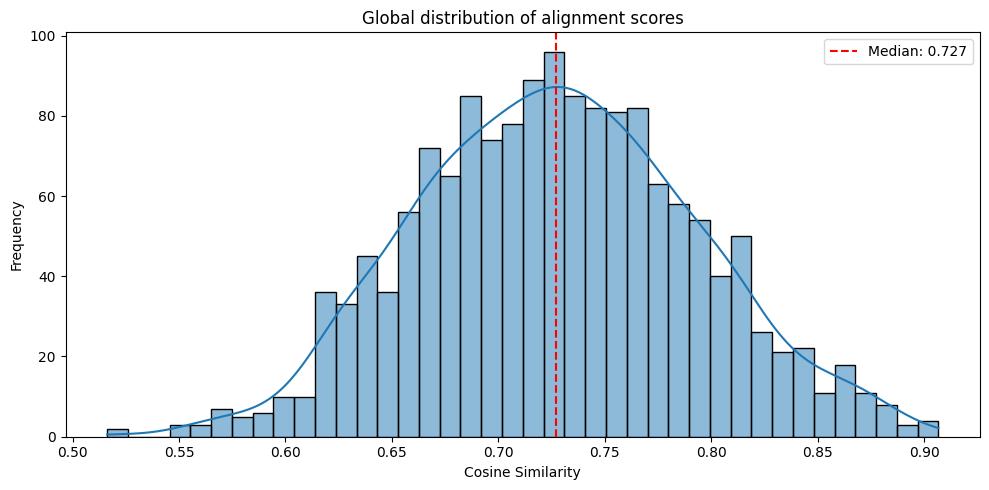

In [5]:
#Global distribution of alignment scores
plt.figure(figsize=(10, 5))
sns.histplot(data["alignment_score"], bins=40, kde=True)
plt.title("Global distribution of alignment scores")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.axvline(data["alignment_score"].mean(), color="red", linestyle="--", label=f"Median: {data['alignment_score'].median():.3f}")
plt.legend()
plt.tight_layout()
plt.show()

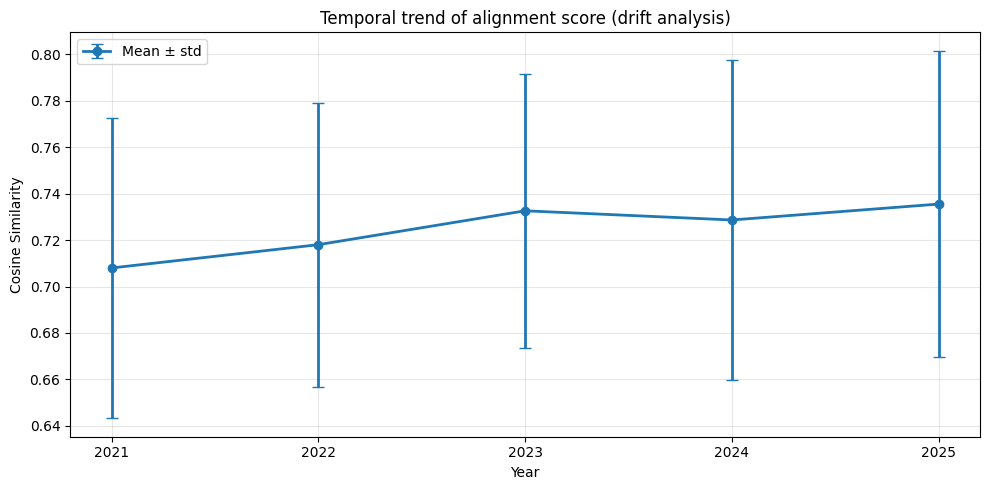

In [6]:
#Drift analysis
#This describes how much the alignemnt takes distance from mean every year.
#This gives us a comparison year by year showing dispersion differences.
yearly = data.groupby("year")["alignment_score"].agg(["mean", "std", "count"])

plt.figure(figsize=(10, 5))
plt.errorbar(
    yearly.index,
    yearly["mean"],
    yerr=yearly["std"],
    marker="o",
    capsize=4,
    linewidth=2,
    label="Mean ± std"
)
plt.title("Temporal trend of alignment score (drift analysis)")
plt.xlabel("Year")
plt.ylabel("Cosine Similarity")
plt.xticks(sorted(data["year"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



In [26]:
N = 10
bottom = data.nsmallest(N, "alignment_score")[["title", "year", "alignment_score"]]

print(f"Top {N} articles with worse alignment to Journal's scope:\n")
display(bottom
        .style
        .hide(axis="index")
        .set_properties(subset=["title"],**{
            "white-space":"nowrap",
            "text-align": "center"
        })
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]},
        ])
       )

title,year,alignment_score
DCM2Net: an improved face recognition model for panoramic stereoscopic videos,2024,0.516277
Conformational Changes of the Receptor Binding Domain of SARS-CoV-2 Spike Protein and Prediction of a B-Cell Antigenic Epitope Using Structural Data,2021,0.525444
Convolutional Neural Network-Based Technique for Gaze Estimation on Mobile Devices,2022,0.551072
Clinical Enhancement in AI-Based Post-processed Fast-Scan Low-Dose CBCT for Head and Neck Adaptive Radiotherapy,2021,0.554394
FLA-UNet: feature-location attention U-Net for foveal avascular zone segmentation in OCTA images,2025,0.554700
BLoss-DDNet: bending loss and dual-task decoding network for overlapping cell nucleus segmentation of cervical clinical LBC images,2025,0.557373
Image restoration in frequency space using complex-valued CNNs,2024,0.561620
Deep learning for steganalysis: evaluating model robustness against image transformations,2025,0.562056
Isolated single sound lip-reading using a frame-based camera and event-based camera,2023,0.568597
NeuroSim Simulator for Compute-in-Memory Hardware Accelerator: Validation and Benchmark,2021,0.569344


In [13]:
#top articles score

N = 10
top = data.nlargest(N, "alignment_score")[["title", "year", "alignment_score"]]
print(f"Top {N} articles more alignment to Journal's scope:\n")
display(top
        .style
        .hide(axis="index")
        .set_properties(subset=["title"],**{
            "white-space":"nowrap",
            "text-align": "center"
        })
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]},
        ])
       )

Top 10 articles more alignment to Journal's scope:



,title,year,alignment_score
0,Ethics dumping in artificial intelligence,2024,0.906679
1,Specific challenges posed by artificial intell...,2023,0.901523
2,AI in humanitarian healthcare: a game changer ...,2025,0.899723
3,What Makes Artificial Intelligence Exceptional...,2021,0.897527
4,"Knowledge, attitude, and practice of artificia...",2022,0.890756
5,Ethical-legal implications of AI-powered healt...,2025,0.890095
6,The imperative of diversity and equity for the...,2025,0.887296
7,Perceptions of health data commodification in ...,2025,0.884043
8,Perceptions of health data commodification in ...,2025,0.884043
9,Using ChatGPT to navigate ambivalent and contr...,2023,0.881297
